In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.manual_seed(42)

device = torch.device("mps" if torch.mps.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


/Users/zoga/Studia-II/Neural-Networks/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [2]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

In [3]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [4]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

## Zad1

In [5]:
# Sposób 1
model_sequential = nn.Sequential(
    nn.Flatten(), # 3072 = 32 * 32 * 3 (HWC)
    nn.Linear(32 * 32 * 3, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

# Sposób 2
class CustomModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

model_custom = CustomModel()

print("Model Sequential")
print(model_sequential)
print("Model Custom")
print(model_custom)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nLiczba parametrów w model_sequential: {count_parameters(model_sequential):,}")
print(f"Liczba parametrów w model_custom: {count_parameters(model_custom):,}")

Model Sequential
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Linear(in_features=256, out_features=10, bias=True)
)
Model Custom
CustomModel(
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)

Liczba parametrów w model_sequential: 1,707,274
Liczba parametrów w model_custom: 1,707,274


**1. What does `torch.nn.Module` represent?**
 * reprezentuje pojdeyczne warstwy sieci lub całą sieć, ma strukture parametórw i funkcję forward

**2. Why does PyTorch automatically track parameters inside a module?**
 * kiedy w __init__ stowrzy sie nowe warstwy pytorch wrzuca to na swoją wewnętrzną listę wag, śledzi je żeby można było efektywnie wykonać uczenie

**3. When is `nn.Sequential` convenient?**
 * wtedy kiedy architektura jest prosta, albo składa się z wielu schematycznych kawałków, które jako pojedyczne sequentialie mozna wrzucić do większej klasy

**4. When is a custom `nn.Module` preferable?**
 * wtedy kiedy model staje sie znacznie wiekszy, sa różne ściezki przepływy danych, własny forward daje też więszke możliwości 

## Zad2

In [6]:
import matplotlib.pyplot as plt

model = MLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
}

epochs = 10

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 01/10 | Train Loss: 2.2291 | Train Acc: 0.1883 | Val Loss: 2.1315 | Val Acc: 0.2648
Epoch 02/10 | Train Loss: 2.0463 | Train Acc: 0.2714 | Val Loss: 1.9987 | Val Acc: 0.2784
Epoch 03/10 | Train Loss: 1.9490 | Train Acc: 0.3081 | Val Loss: 1.9209 | Val Acc: 0.3196
Epoch 04/10 | Train Loss: 1.8910 | Train Acc: 0.3301 | Val Loss: 1.8766 | Val Acc: 0.3334
Epoch 05/10 | Train Loss: 1.8485 | Train Acc: 0.3452 | Val Loss: 1.8368 | Val Acc: 0.3520
Epoch 06/10 | Train Loss: 1.8122 | Train Acc: 0.3582 | Val Loss: 1.8038 | Val Acc: 0.3612
Epoch 07/10 | Train Loss: 1.7792 | Train Acc: 0.3697 | Val Loss: 1.7709 | Val Acc: 0.3730
Epoch 08/10 | Train Loss: 1.7502 | Train Acc: 0.3783 | Val Loss: 1.7529 | Val Acc: 0.3806
Epoch 09/10 | Train Loss: 1.7245 | Train Acc: 0.3899 | Val Loss: 1.7397 | Val Acc: 0.3864
Epoch 10/10 | Train Loss: 1.7009 | Train Acc: 0.3972 | Val Loss: 1.6988 | Val Acc: 0.4030


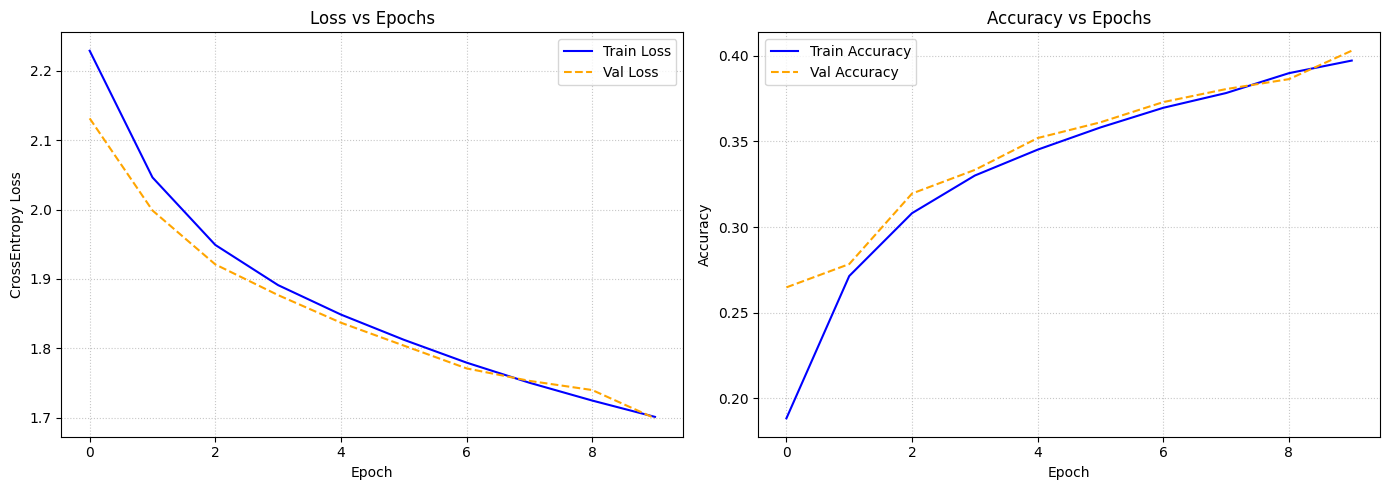

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='orange', linestyle='--')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].plot(history['train_acc'], label='Train Accuracy', color='blue')
axes[1].plot(history['val_acc'], label='Val Accuracy', color='orange', linestyle='--')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

**1. Why do we use mini-batches?**
 * Cały zbiór danych może nie zmieścić się w RAMie, lepiej trening robic kawałkami
 * akualiujemy wagi cześciej, co bardziej pasuje do szukania odpowiedniego kierunku
 * gradient w mini-batchu jest tylko przybliżeniem tego rzeczywistego, ale to moze pomoc w wyarwaniu sie z loklanych miniów


**2. What do `model.train()` and `model.eval()` do?**
 * te funkcje działają jak przełączniki trybu modelu, w pierwszy model sie uczy i liczy gradienty, w drugim jedynie korzsyta z tego co ustalił
 * niektore elementy archiektury mają działać np jedynie podczas treninigu, np `dropout` który losowo zeruje niektóre wagi nie ma sensu w `evalu`

**3. Why are gradients disabled during validation (`torch.no_grad()`)?**
 * podczas walidacji nie chcemy niż nic liczyc dodatkowego ani modyfikować, sprawdzamy, wiec nie ma co sensu liczyć

**4. Why is `optimizer.zero_grad()` necessary?**
 * po to żeby pochodne w koljnych krokach sie nie akulumowały, jeśli stoimy w pewnym punkcie dziedziny, potem akualizujemy pozycje zgodnie z gradientem, to w tej nowej pozycji wyliczony gradient jest już nieaktualny i nalezy liczyć go od nowa

## Zad3

In [8]:
epochs = 10
criterion = nn.CrossEntropyLoss()

optimizer_configs = {
    "SGD": lambda params: torch.optim.SGD(params, lr=0.1),
    "SGD+Momentum": lambda params: torch.optim.SGD(params, lr=0.01, momentum=0.9),
    "SGD+Nesterov": lambda params: torch.optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True),
    "RMSprop": lambda params: torch.optim.RMSprop(params, lr=0.001),
    "Adam": lambda params: torch.optim.Adam(params, lr=0.001),
}

results = {}
final_metrics = []

In [9]:
for opt_name, opt_func in optimizer_configs.items():
    model = MLP().to(device)

    optimizer = opt_func(model.parameters())
    
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(val_loss)
        hist['train_acc'].append(train_acc)
        hist['val_acc'].append(val_acc)
    
    print(f"[{opt_name}] Final Val Acc: {hist['val_acc'][-1]:.4f}")
    results[opt_name] = hist
    
    final_metrics.append({
        "Optimizer": opt_name,
        "Learning Rate": optimizer.param_groups[0]['lr'],
        "Final Train Loss": hist['train_loss'][-1],
        "Final Val Loss": hist['val_loss'][-1],
        "Final Train Acc": hist['train_acc'][-1],
        "Final Val Acc": hist['val_acc'][-1]
    })

[SGD] Final Val Acc: 0.4740
[SGD+Momentum] Final Val Acc: 0.5084
[SGD+Nesterov] Final Val Acc: 0.5098
[RMSprop] Final Val Acc: 0.4746
[Adam] Final Val Acc: 0.5008


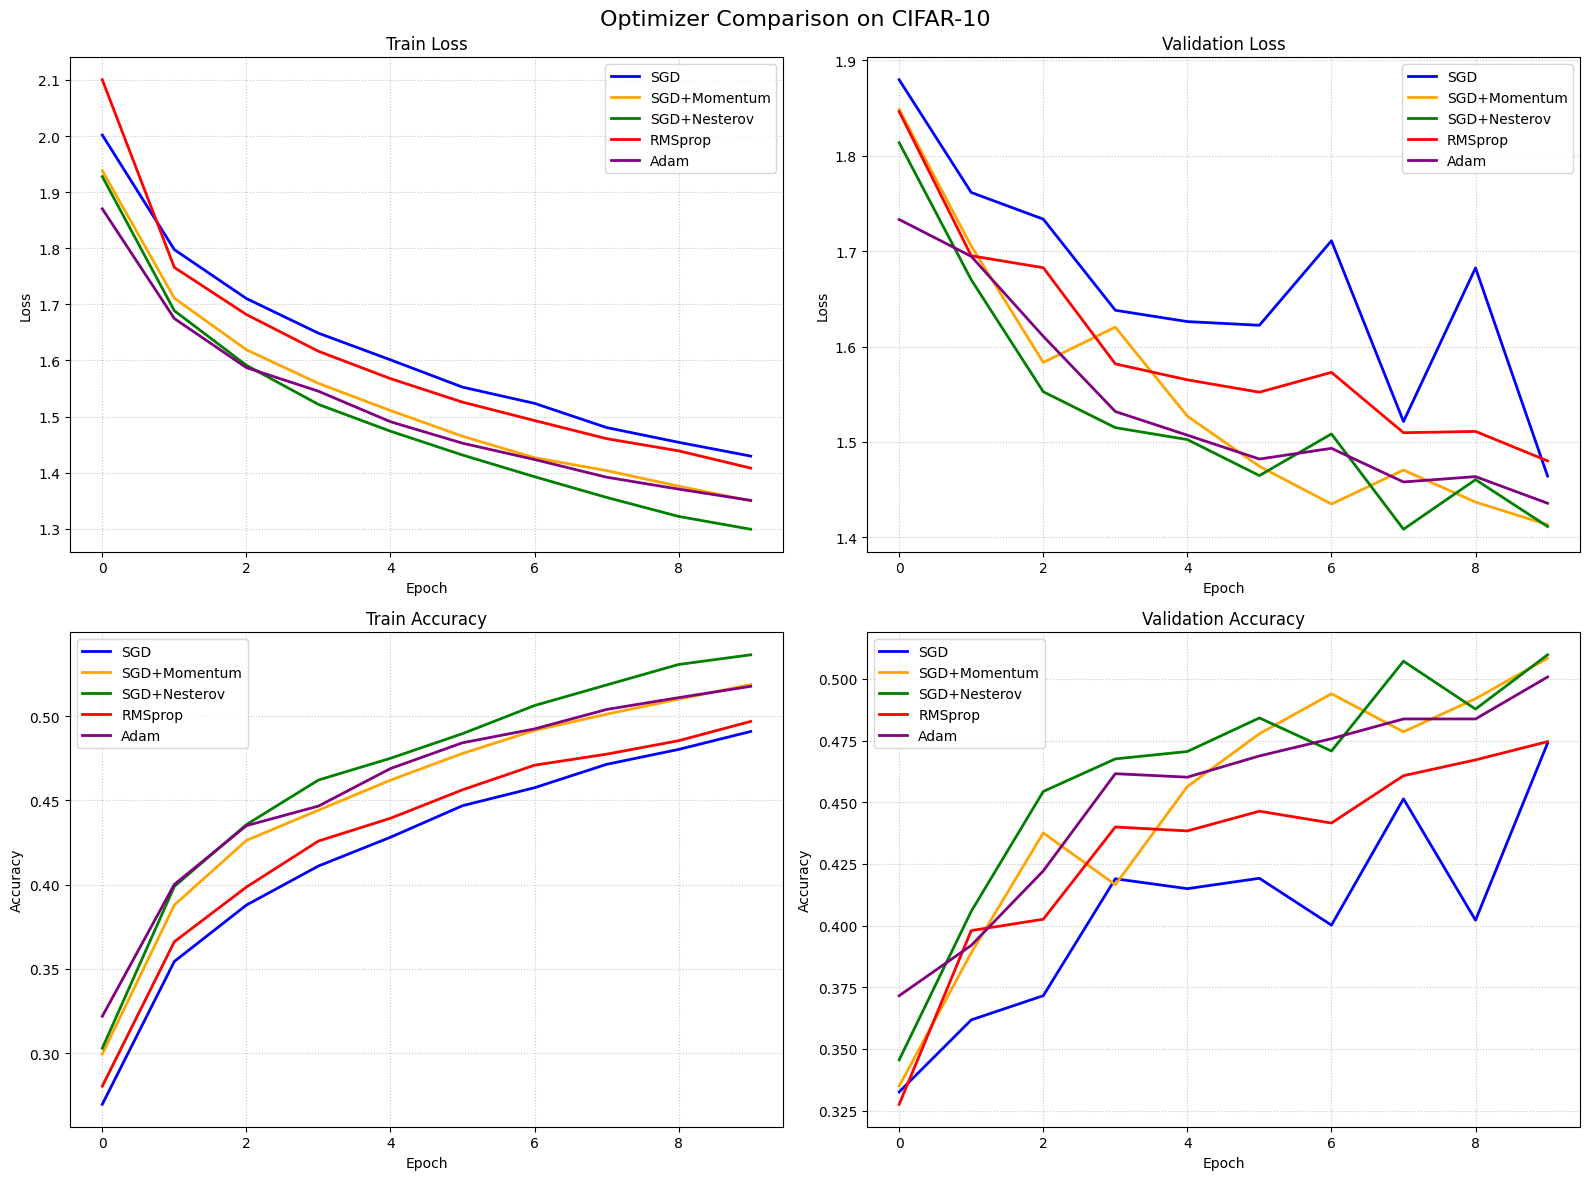

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Optimizer Comparison on CIFAR-10", fontsize=16)

metrics = [
    ('train_loss', 'Train Loss', axes[0, 0]),
    ('val_loss', 'Validation Loss', axes[0, 1]),
    ('train_acc', 'Train Accuracy', axes[1, 0]),
    ('val_acc', 'Validation Accuracy', axes[1, 1])
]

colors = {'SGD': 'blue', 'SGD+Momentum': 'orange', 'SGD+Nesterov': 'green', 'RMSprop': 'red', 'Adam': 'purple'}

for metric_key, metric_title, ax in metrics:
    for opt_name, hist in results.items():
        ax.plot(hist[metric_key], label=opt_name, color=colors[opt_name], linewidth=2)
    ax.set_title(metric_title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric_title.split()[-1])
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

df_results = pd.DataFrame(final_metrics)
print("\nPodsumowanie")
display(df_results)


Podsumowanie


,Optimizer,Learning Rate,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc
0,SGD,0.100,1.429486,1.464194,0.490867,0.4740
1,SGD+Momentum,0.010,1.349685,1.413269,0.518711,0.5084
2,SGD+Nesterov,0.010,1.299090,1.411366,0.536378,0.5098
3,RMSprop,0.001,1.408120,1.480173,0.496844,0.4746
4,Adam,0.001,1.350571,1.435748,0.517667,0.5008


**1. Which optimizer converged fastest?**
 * Adam i Momentum zadaje się być najszybszy

**2. Which optimizer achieved the best validation result?**
 * Adam i Momentum osiąga najlepsze wyniki na train i val

**3. Did adaptive methods behave differently from SGD?**
 * tak, bo one modyfikuje lr w czasie treningu

znalałzem fajny link: https://www.digitalocean.com/community/tutorials/intro-to-optimization-momentum-rmsprop-adam

są tam też rzeczy o których mówiłem na jednych z porzednich zajeć

**4. Did Momentum / Nesterov improve over plain SGD?**
 * w tym teście spisały się zauważalnie gorzej

Momentum – działa tak, że bierze część (momentum) poprzedniego kierunku a tylko część nowego gradientu. Analogia (nie do końca realnie fizyczna) jest do kuli która sie toczy i nabiera pędu w pewnym kieurnku, lokalne zminy nie przeważają nad globalnym kierunkiem

Nesterov – to troche sprytenijsza metoda, która przed korkiem robi stuczny krok do przodu, liczy gradient w tym nowym punckie i akualizuje wczesznieszy krok o tą wartość, troche jak uśrednieni następnych kroków

RMSprop – dopasowuje lr do różnych parametrów, tam gdzie potrzeba wiekszych ruchów robi większa a tam gdzie mniejsze to mniejsze

Adam – to po prostu połącznie Momentum i RMSprop 

## Zad4

In [12]:
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(3072, 512), nn.ReLU(),
            nn.Linear(512, 256),  nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, 10)
        ])
        
    def forward(self, x, return_acts=False):
        x = torch.flatten(x, start_dim=1)
        
        activations = []
        for layer in self.layers:
            x = layer(x)
            if isinstance(layer, nn.ReLU):
                activations.append(x)
        if return_acts:
            return x, activations
        return x 

In [13]:
def apply_init(model, method):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if method == "Normal (std=0.01)":
                nn.init.normal_(m.weight, mean=0, std=0.01)
            elif method == "Normal (std=1.0)":
                nn.init.normal_(m.weight, mean=0, std=1.0)
            elif method == "Xavier":
                nn.init.xavier_normal_(m.weight)
            elif method == "He":
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)

In [14]:
init_methods = ["Normal (std=0.01)", "Normal (std=1.0)", "Xavier", "He"]
stats = {name: {'act_mean': [], 'act_var': [], 'grad_var': []} for name in init_methods}

dummy_x = torch.randn(128, 32*32*3)
dummy_y = torch.randint(0, 10, (128,))
criterion = nn.CrossEntropyLoss()

for init in init_methods:
    model = DeepMLP()
    apply_init(model, init)
    
    # Forward Pass
    logits, activations = model(dummy_x, return_acts=True)
    for act in activations:
        stats[init]['act_mean'].append(act.mean().item())
        stats[init]['act_var'].append(act.var().item())
        
    # Backward Pass
    loss = criterion(logits, dummy_y)
    loss.backward()
    
    for m in model.modules():
        if isinstance(m, nn.Linear) and m.weight.grad is not None:
            stats[init]['grad_var'].append(m.weight.grad.var().item())

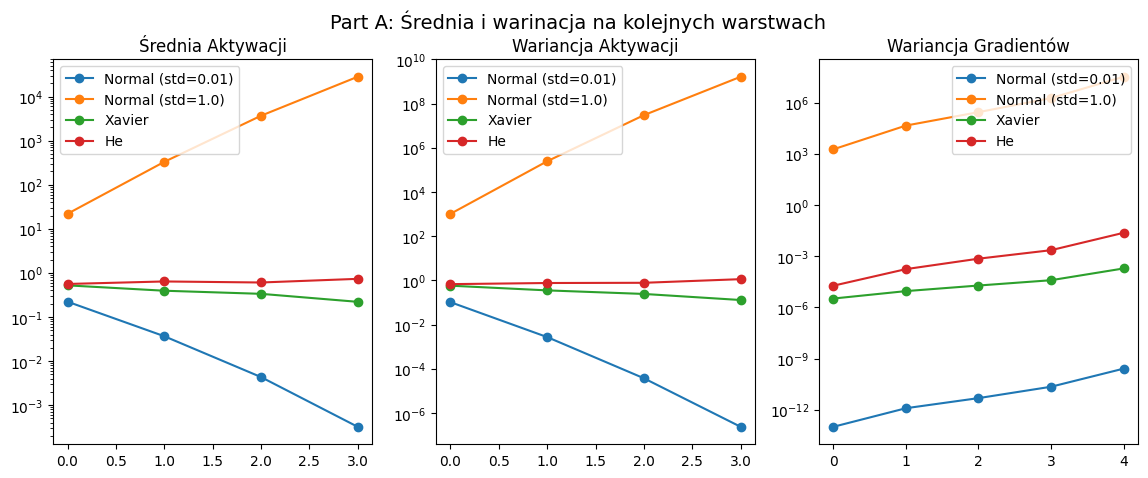

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Part A: Średnia i warinacja na kolejnych warstwach", fontsize=14)

for init in init_methods:
    axes[0].plot(stats[init]['act_mean'], marker='o', label=init)
    axes[1].plot(stats[init]['act_var'], marker='o', label=init)
    axes[2].plot(stats[init]['grad_var'], marker='o', label=init)

axes[0].set_title("Średnia Aktywacji")
axes[0].set_yscale('log')
axes[0].legend()

axes[1].set_title("Wariancja Aktywacji")
axes[1].set_yscale('log')
axes[1].legend()

axes[2].set_title("Wariancja Gradientów")
axes[2].set_yscale('log')
axes[2].legend()
plt.show()

In [16]:
epochs = 5
results_b = {}

for init in init_methods:
    print(f"Trenowanie: {init}...")
    model = DeepMLP().to(device)
    apply_init(model, init)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    hist = {'train_loss': [], 'val_acc': [], 'grad_norm': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss, total_samples = 0, 0
        total_grad_norm = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            
            batch_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    batch_norm += p.grad.norm().item() ** 2
            total_grad_norm += batch_norm ** 0.5
            
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            total_samples += x.size(0)
            
        hist['train_loss'].append(total_loss / total_samples)
        hist['grad_norm'].append(total_grad_norm / len(train_loader))
        
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        hist['val_acc'].append(val_acc)
        
    results_b[init] = hist

Trenowanie: Normal (std=0.01)...
Trenowanie: Normal (std=1.0)...
Trenowanie: Xavier...
Trenowanie: He...


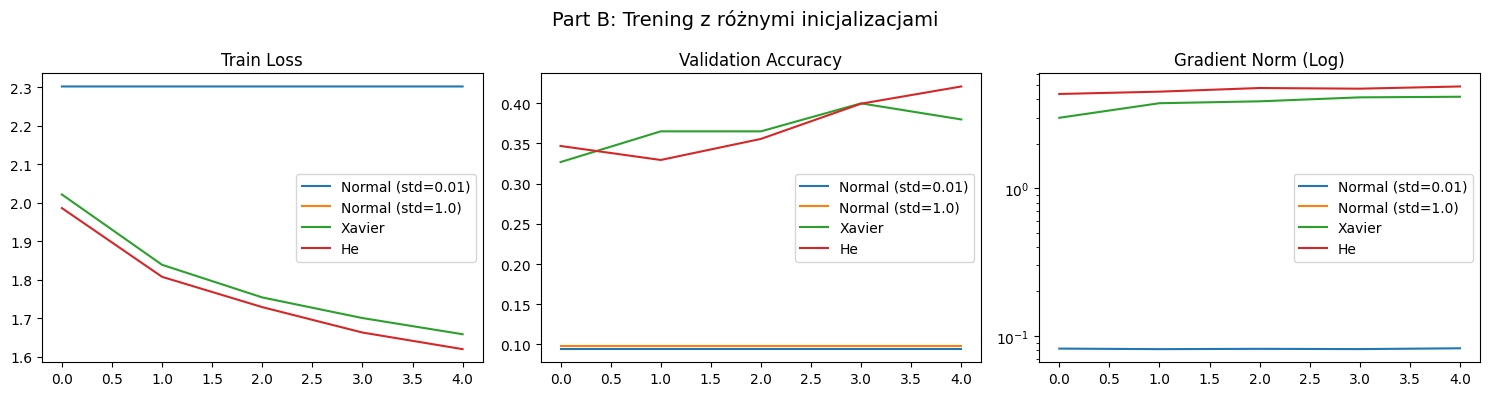

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Part B: Trening z różnymi inicjalizacjami", fontsize=14)

for init in init_methods:
    axes[0].plot(results_b[init]['train_loss'], label=init)
    axes[1].plot(results_b[init]['val_acc'], label=init)
    axes[2].plot(results_b[init]['grad_norm'], label=init)

axes[0].set_title("Train Loss")
axes[1].set_title("Validation Accuracy")
axes[2].set_title("Gradient Norm (Log)")
axes[2].set_yscale('log')

for ax in axes: ax.legend()
plt.tight_layout()
plt.show()

**1.why initialization matters**
 * źle dobrane wagi poczatkowe sprawiją, że sygnał albo szybko maleje do zera albo eksploduje, dobra inzjalizaja poiwnna być stablina, normalizujca wariancje sygnału

**2.why He initialization is usually good for ReLU networks**
 * relu zeruje ujmen wartości, He zwieksza wariancje danych co pozwala utrzymać sygnał, bo jest po prostu większy

**3.when Xavier initialization is more natural**
 * dla symetrycznych funkcji aktywacji jak `tanh` czy `sigmoid`, dlatego że w okolicach zera funkcje te zachowują się niemal liniowo i zachowuja wariancje

**4.whether poor initialization can contribute to vanishing or exploding activations/gradients**
 * tak, zbyt duże wagi (np. std=1.0) lawinowo pompują sygnał z każdą warstwą, co kończy się błędem eksplozją gradientu. Zbyt małe wagi (np. std=0.01) tłumią sygnał do zera, przez co wagi całkowicie przestają się aktualizować.

**5.whether random normalized input noise was useful for isolating the effect of initialization**
* wydaje mi się, że sam losowy input jest na tych wykresach dobrnym wyznacznikiem

## Task 5 — Optimizers

### Momentum vs Nesterov
Oba korzystają z Exponential Moving Average po zeszłych gradientach, ale różnią się punktami ewaluacji 
* **Momentum:** liczy gradient w $\theta_{t-1}$, następnie dodaje "pęd"
  $$v_t = \beta v_{t-1} - \eta \nabla L_{\theta}(\theta_{t-1})$$
  $$\theta_t = \theta_{t-1} + v_t$$
* **Nesterov (NAG):** Oznaczmy wagi widoczne w naszym kodzie jako $\Theta$. Definiujemy je zawsze o jeden krok pędu do przodu względem teoretycznych, prawdziwych wag $\theta$:$$\Theta_t = \theta_t + \beta v_t$$

Skoro w modelu mamy $\Theta_{t-1}$, gradient liczymy z obecnych wag: $g_t = \nabla L(\Theta_{t-1})$.Prędkość aktualizujemy identycznie jak w zwykłym Momentum:$$v_t = \beta v_{t-1} - \eta g_t$$Z klasycznego Momentum wiemy, że prawdziwe wagi zaktualizowałyby się tak: $\theta_t = \theta_{t-1} + v_t$. Wstawmy to do naszej początkowej definicji $\Theta_t$:$$\Theta_t = (\theta_{t-1} + v_t) + \beta v_t$$Z definicji z poprzedniego kroku wiemy, że $\Theta_{t-1} = \theta_{t-1} + \beta v_{t-1}$. Przekształcając to, otrzymujemy $\theta_{t-1} = \Theta_{t-1} - \beta v_{t-1}$. Podstawmy to do powyższego równania:$$\Theta_t = (\Theta_{t-1} - \beta v_{t-1}) + v_t + \beta v_t$$Otrzymujemy$$\Theta_t = \Theta_{t-1} + v_t + \beta (v_t - v_{t-1})$$Wniosek: Dodatkowy człon $\beta(v_t - v_{t-1})$ w locie koryguje naszą trajektorię. 

### Jak RMSprop adaptuje rozmiar kroku
RMSprop radzi sobie z różnym nachyleniem na poszczególnych osiach. Utrzymuje wykładniczą średnią ruchomą **kwadratów gradientów** $s_t$:
$$s_t = \rho s_{t-1} + (1 - \rho) g_t^2$$
Aktualizacja parametrów jest skalowana przez pierwiastek z tej średniej:
$$\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{s_t} + \epsilon} g_t$$
Dzięki temu na osiach ze stromym spadkiem (duże $s_t$) krok jest zmniejszany (zapobiega rozbieżnościom), a na osiach płaskich (małe $s_t$) krok jest relatywnie większy, co przyspiesza zbieżność.

### Jak Adam łączy Momentum i adaptacyjne skalowanie
Adam łączy siłę Momentum i RMSprop, dodając do nich **bias correction**.
1. **Pierwszy moment (Momentum):** Średnia ruchoma gradientów: $m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$.
2. **Drugi moment (RMSprop):** Średnia ruchoma kwadratów gradientów: $v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$.
3. **Korekta obciążenia:** Ponieważ wartości początkowe $m_0$ i $v_0$ to zera, w pierwszych krokach są one mocno zaniżone. Adam to koryguje:
   $$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
4. **Zasada aktualizacji:** Łączy oba ulepszone momenty:
   $$\theta_t = \theta_{t-1} - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

In [18]:
class Momentum:
    def __init__(self, parameters, lr=0.01, momentum=0.9):
        self.params = list(parameters)
        self.lr = lr
        self.momentum = momentum

        self.v = [torch.zeros_like(p) for p in self.params]

    @torch.no_grad()
    def step(self):
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            
            g_t = p.grad
            
            self.v[i] = self.momentum * self.v[i] - self.lr * g_t
            
            p.add_(self.v[i])

In [19]:
class Nesterov:
    def __init__(self, parameters, lr=0.01, momentum=0.9):
        self.params = list(parameters)
        self.lr = lr
        self.momentum = momentum
        self.v = [torch.zeros_like(p) for p in self.params]

    @torch.no_grad()
    def step(self):
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            
            g_t = p.grad
            v_t_minus_1 = self.v[i].clone() 

            # v_t = \beta v_{t-1} - \eta g_t
            self.v[i] = self.momentum * self.v[i] - self.lr * g_t

            # \Theta_t = \Theta_{t-1} + v_t + \beta (v_t - v_{t-1})
            step_nesterov = self.v[i] + self.momentum * (self.v[i] - v_t_minus_1)
            p.add_(step_nesterov)

In [20]:
class RMSprop:
    def __init__(self, parameters, lr=0.01, rho=0.99, eps=1e-8):
        self.params = list(parameters)
        self.lr = lr
        self.rho = rho
        self.eps = eps
        
        # Zamiast prędkości (jak w Momentum), trzymamy średnią kwadratów gradientów (s_t)
        self.s = [torch.zeros_like(p) for p in self.params]

    @torch.no_grad()
    def step(self):
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            
            g_t = p.grad
            
            # s_t = rho * s_{t-1} + (1 - rho) * g_t^2
            self.s[i] = self.rho * self.s[i] + (1 - self.rho) * (g_t ** 2)
            
            denominator = torch.sqrt(self.s[i]) + self.eps
            
            step_rmsprop = (self.lr / denominator) * g_t
            
            p.sub_(step_rmsprop)

In [21]:
class Adam:
    def __init__(self, parameters, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = list(parameters)
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
        self.t = 0 

    @torch.no_grad()
    def step(self):
        self.t += 1 
        
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            
            g_t = p.grad
            
            # Pierwszy moment (Momentum)
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g_t
            # Drugi moment (RMSprop)
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g_t ** 2)
            
            # Bias correction (Korekta obciążenia)
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)
            
            # Skalowany krok
            step_adam = (self.lr / (torch.sqrt(v_hat) + self.eps)) * m_hat
            
            # Aktualizacja wag
            p.sub_(step_adam)

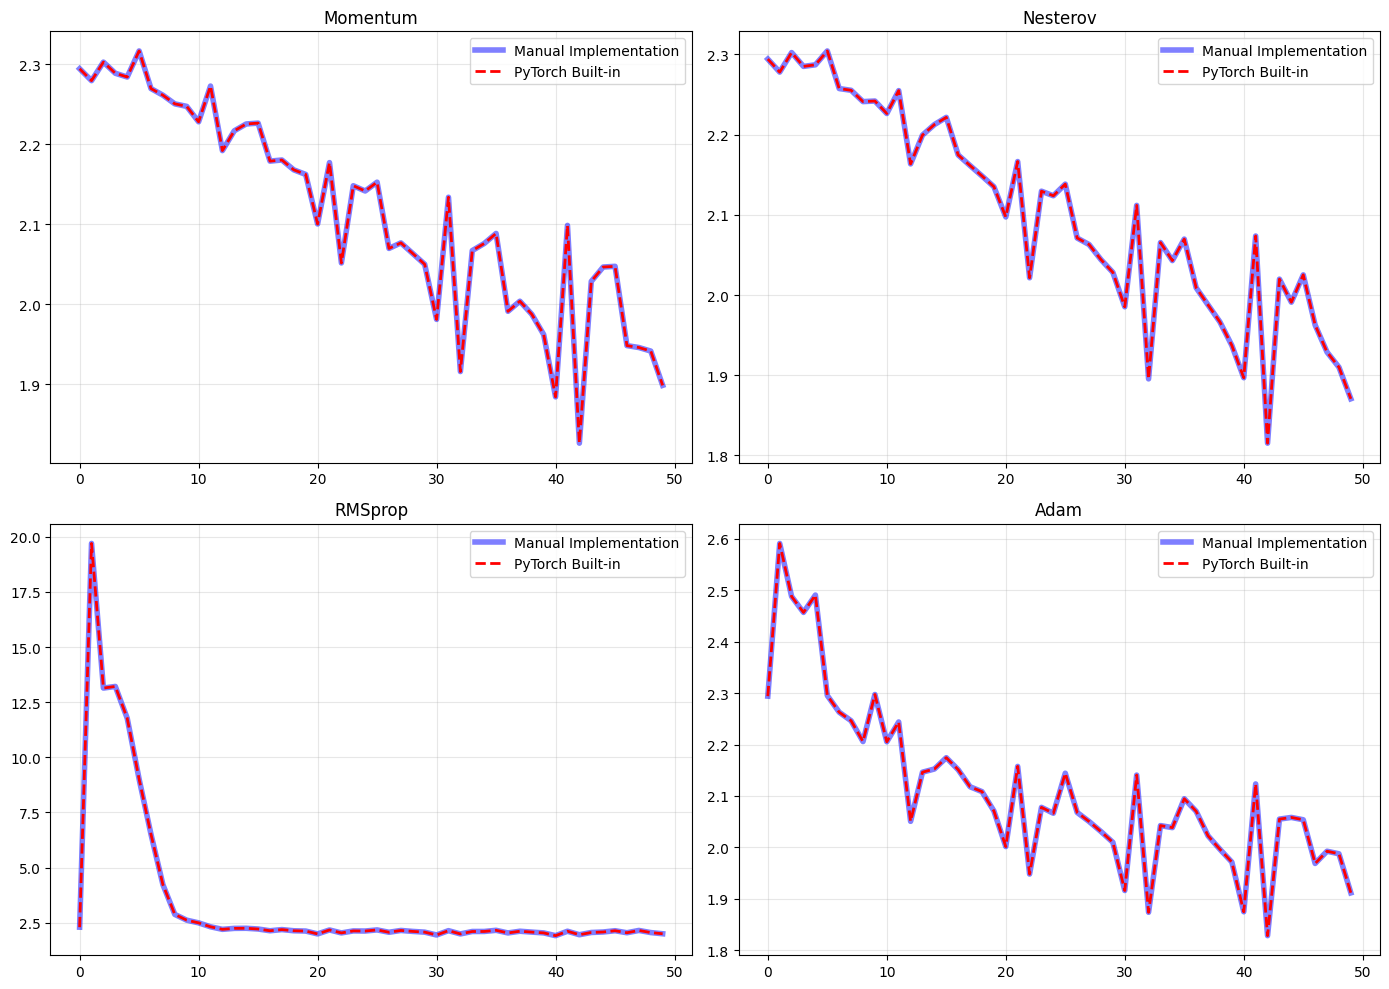

In [22]:
import copy

class SmallMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

mini_loader = [next(iter(train_loader)) for _ in range(10)] * 5 

base_model = SmallMLP().to(device)
criterion = nn.CrossEntropyLoss()

configs = {
    "Momentum": (
        lambda params: Momentum(params, lr=0.01, momentum=0.9),
        lambda params: torch.optim.SGD(params, lr=0.01, momentum=0.9)
    ),
    "Nesterov": (
        lambda params: Nesterov(params, lr=0.01, momentum=0.9),
        lambda params: torch.optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True)
    ),
    "RMSprop": (
        lambda params: RMSprop(params, lr=0.001, rho=0.99),
        lambda params: torch.optim.RMSprop(params, lr=0.001, alpha=0.99)
    ),
    "Adam": (
        lambda params: Adam(params, lr=0.001),
        lambda params: torch.optim.Adam(params, lr=0.001)
    )
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, (manual_opt_fn, torch_opt_fn)) in enumerate(configs.items()):
    # Model z naszym optymalizatorem
    model_manual = copy.deepcopy(base_model)
    opt_manual = manual_opt_fn(model_manual.parameters())
    
    # Model z optymalizatorem PyTorch
    model_torch = copy.deepcopy(base_model)
    opt_torch = torch_opt_fn(model_torch.parameters())

    losses_manual, losses_torch = [], []

    for x, y in mini_loader:
        x, y = x.to(device), y.to(device)
        
        # Ręczny trening
        for p in model_manual.parameters():
            if p.grad is not None: 
                p.grad.zero_()
        loss_m = criterion(model_manual(x), y)
        loss_m.backward()
        opt_manual.step()
        losses_manual.append(loss_m.item())
        
        # PyTorch trening
        opt_torch.zero_grad()
        loss_t = criterion(model_torch(x), y)
        loss_t.backward()
        opt_torch.step()
        losses_torch.append(loss_t.item())

    # krzywe powinny na siebie całkowicie nachodzić
    axes[idx].plot(losses_manual, label='Manual Implementation', color='blue', linewidth=4, alpha=0.5)
    axes[idx].plot(losses_torch, label='PyTorch Built-in', color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(name)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Manualne optimizery zgzadzją się z tymi z Optim.